# Сравнение моделей Breast Cancer

Цель этапа - сравнить Logistic Regression, SVC, RandomForestClassifier и MLPClassifier на едином preprocessing pipeline.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from experiment_utils import (
    calculate_binary_metrics,
    load_breast_cancer_data,
    save_figure,
    save_results,
    split_breast_cancer_features_target,
)

POSITIVE_LABEL = "malignant"
TEST_SIZE = 0.2
RANDOM_STATE = 42

def positive_proba(model, X, positive_label=POSITIVE_LABEL):
    classifier = model.named_steps["classifier"]
    positive_index = list(classifier.classes_).index(positive_label)
    return model.predict_proba(X)[:, positive_index]

def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = positive_proba(pipeline, X_test)
    metrics = calculate_binary_metrics(y_test, y_pred, y_proba, POSITIVE_LABEL)
    return metrics, pipeline, y_pred, y_proba

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")


In [2]:
df = load_breast_cancer_data()
X, y = split_breast_cancer_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


## Единый pipeline

Для всех моделей используется `SimpleImputer` и `StandardScaler`. Для RandomForest масштабирование технически не обязательно, но оставлено для единообразия эксперимента.

In [3]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, solver="liblinear"),
    "SVC": SVC(kernel="linear", probability=True, random_state=42),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42),
}

rows = []
for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", estimator),
    ])
    metrics, fitted_model, _, _ = evaluate_pipeline(model_name, pipeline, X_train, X_test, y_train, y_test)
    rows.append({
        "Dataset": "Breast Cancer",
        "Experiment": "Models comparison",
        "Model": model_name,
        "Preprocessing": "SimpleImputer + StandardScaler",
        **metrics,
    })

results = pd.DataFrame(rows).round(4)
save_results(results, RESULTS_DIR / "breast_cancer_models_comparison_results.csv")
results


,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Breast Cancer,Models comparison,LogisticRegression,SimpleImputer + StandardScaler,0.9737,0.9639,0.9960
1,Breast Cancer,Models comparison,SVC,SimpleImputer + StandardScaler,0.9649,0.9500,0.9914
2,Breast Cancer,Models comparison,RandomForestClassifier,SimpleImputer + StandardScaler,0.9649,0.9500,0.9942
3,Breast Cancer,Models comparison,MLPClassifier,SimpleImputer + StandardScaler,0.9649,0.9500,0.9927


## Графики сравнения моделей

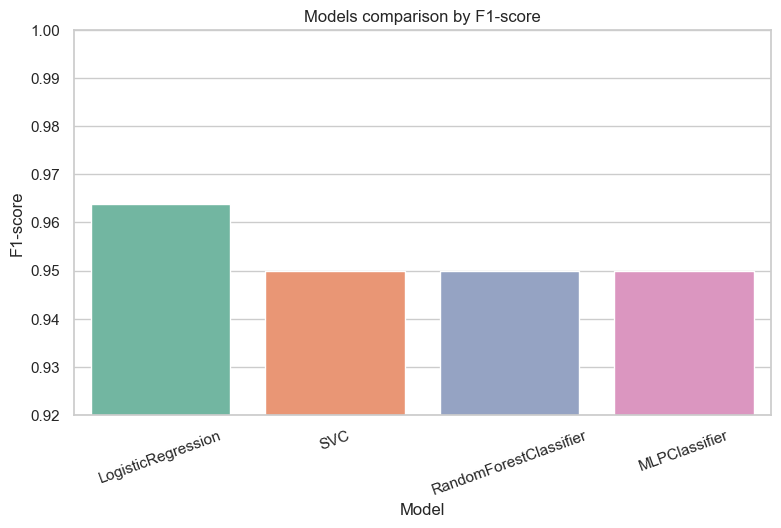

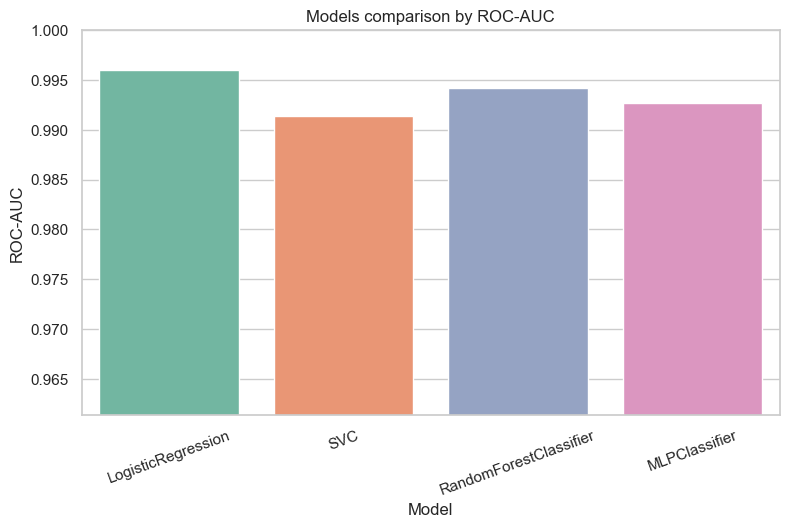

In [4]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Model", y="F1-score", hue="Model", palette="Set2", legend=False)
plt.ylim(max(0, results["F1-score"].min() - 0.03), 1.0)
plt.title("Models comparison by F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
save_figure(FIGURES_DIR / "breast_cancer_models_comparison_f1.png")
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=results, x="Model", y="ROC-AUC", hue="Model", palette="Set2", legend=False)
plt.ylim(max(0, results["ROC-AUC"].min() - 0.03), 1.0)
plt.title("Models comparison by ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=20)
save_figure(FIGURES_DIR / "breast_cancer_models_comparison_roc_auc.png")
plt.show()


## Итоговый вывод

In [5]:
best_f1 = results.loc[results["F1-score"].idxmax()]
best_roc_auc = results.loc[results["ROC-AUC"].idxmax()]
print(f"Лучшая модель по F1-score: {best_f1['Model']} ({best_f1['F1-score']:.4f})")
print(f"Лучшая модель по ROC-AUC: {best_roc_auc['Model']} ({best_roc_auc['ROC-AUC']:.4f})")

Лучшая модель по F1-score: LogisticRegression (0.9639)
Лучшая модель по ROC-AUC: LogisticRegression (0.9960)


На Breast Cancer все модели показывают высокое качество, потому что признаки хорошо разделяют классы. Отличия между алгоритмами меньше, чем на Adult Census, где есть категориальные признаки, пропуски и более выраженный дисбаланс классов.